<a href="https://colab.research.google.com/github/PetrosPolychronopoulos/IBM-Profecional-Data-Analyst-Certificate/blob/main/BERT_train_LEDA_test_FLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train BERT on LEDA → Test on FLIP

This notebook trains a multilingual BERT model on the **LEDA** dataset (Dutch/French/German ingredients) and evaluates it on the **FLIP** dataset (Canadian/English ingredients) for NOVA classification (1–4).

**Key design choices:**
- Uses `bert-base-multilingual-cased` so the model can handle both LEDA's multilingual ingredients and FLIP's English ingredients
- `pythonlabel` is 0-indexed (0 = NOVA 1, 3 = NOVA 4) in both datasets — mapped directly to one-hot positions (no off-by-one)
- LEDA ingredients have wrapping quotes that are stripped during preprocessing
- Stratified train/validation split on LEDA; FLIP is used as a fully held-out external test set

**Datasets:**
- Train: `NOVA_GPT_train.csv` — 42,568 products (LEDA, multilingual)
- External test: `FLIP_processed_4.csv` — 15,306 products (FLIP, English)

## 1. Setup

In [1]:
!pip install -q torch transformers datasets scikit-learn evaluate accelerate pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import pickle as pkl

from datasets import load_dataset, Dataset
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import matplotlib.pyplot as plt

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Upload Datasets

Upload both:
1. `NOVA_GPT_train.csv` (LEDA — training data)
2. `FLIP_processed_4.csv` (FLIP — external test data)

In [3]:
from google.colab import files

print("Upload the LEDA training file (NOVA_GPT_train.csv):")
uploaded = files.upload()
LEDA_PATH = list(uploaded.keys())[0]
print(f"LEDA file: {LEDA_PATH}")

print("\nUpload the FLIP test file (FLIP_processed_4.csv):")
uploaded = files.upload()
FLIP_PATH = list(uploaded.keys())[0]
print(f"FLIP file: {FLIP_PATH}")

Upload the LEDA training file (NOVA_GPT_train.csv):


Saving NOVA_GPT_train.csv to NOVA_GPT_train.csv
LEDA file: NOVA_GPT_train.csv

Upload the FLIP test file (FLIP_processed_4.csv):


Saving FLIP_processed (4).csv to FLIP_processed (4).csv
FLIP file: FLIP_processed (4).csv


## 3. Explore Both Datasets

In [4]:
leda_df = pd.read_csv(LEDA_PATH)
flip_df = pd.read_csv(FLIP_PATH)

print("=" * 60)
print("LEDA (Training Data)")
print("=" * 60)
print(f"Shape: {leda_df.shape}")
print(f"Columns: {list(leda_df.columns)}")
print(f"\nLabel distribution (pythonlabel):")
print(leda_df["pythonlabel"].value_counts().sort_index())
print(f"\nSample ingredients:")
for i in range(3):
    print(f"  label={leda_df.pythonlabel.iloc[i]}: {str(leda_df.ingredients.iloc[i])[:80]}")

print(f"\n{'=' * 60}")
print("FLIP (External Test Data)")
print("=" * 60)
print(f"Shape: {flip_df.shape}")
print(f"Columns: {list(flip_df.columns)}")
print(f"\nLabel distribution (pythonlabel):")
print(flip_df["pythonlabel"].value_counts().sort_index())
print(f"\nSample ingredients:")
for i in range(3):
    print(f"  label={flip_df.pythonlabel.iloc[i]}: {str(flip_df.ingredients.iloc[i])[:80]}")

LEDA (Training Data)
Shape: (42568, 6)
Columns: ['PDT_NEVOCODE_PRECIES', 'PRODNAAM_CLEAN', 'CPV_INGREDIENTTEKST', 'NOVAclass', 'pythonlabel', 'ingredients']

Label distribution (pythonlabel):
pythonlabel
0.0     7902
1.0      608
2.0     8761
3.0    25297
Name: count, dtype: int64

Sample ingredients:
  label=0.0: "Rode bieten"
  label=2.0: "Sulfieten"
  label=2.0: "Water, GERSTEMOUT, hop"

FLIP (External Test Data)
Shape: (15306, 11)
Columns: ['product_name', 'ingredients_text', 'novaclass', 'proteins_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'sodium_100g', 'pythonlabel', 'ingredients']

Label distribution (pythonlabel):
pythonlabel
0     1617
1      323
2     1942
3    11424
Name: count, dtype: int64

Sample ingredients:
  label=3: cherries, sugar, corn syrup, enriched flour (wheat flour, niacin, iron, thiamin 
  label=0: natural coconut water not from concentrate.
  label=3: enriched wheat flour, water, modified corn starch, canola oil, dextrose, 

## 4. Configuration

In [5]:
# ─── Configuration ────────────────────────────────────────────────────────────
MODEL_NAME = "leda_to_flip"
MODEL_FOLDER = "trained_leda_model"
BERT_BASE = "bert-base-multilingual-cased"  # Multilingual: handles Dutch/French/German + English
VALIDATION_RATIO = 0.1                       # 10% of LEDA held out for validation during training
MAX_LENGTH = 256
NUM_EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
NUM_LABELS = 4
LABEL_NAMES = ["NOVA 1", "NOVA 2", "NOVA 3", "NOVA 4"]

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create output folder
os.makedirs(MODEL_FOLDER, exist_ok=True)

Using device: cuda


## 5. Preprocessing Functions

In [6]:
def clean_ingredients(text):
    """
    Clean ingredient text.
    LEDA ingredients have wrapping quotes like '"Water, mout, hop"' — strip them.
    """
    if pd.isna(text):
        return ""
    text = str(text).strip()
    # Remove wrapping double quotes (from LEDA GPT output)
    if text.startswith('"') and text.endswith('"'):
        text = text[1:-1]
    return text.strip()


def preprocess_data(examples):
    """
    Tokenize ingredients and one-hot encode labels.

    pythonlabel is 0–3 (NOVA 1–4) in both datasets.
    One-hot position = pythonlabel directly (no -1 shift).
    """
    text = examples["ingredients"]
    pythonlabels = examples["pythonlabel"]

    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=MAX_LENGTH)

    labels_array = np.array(pythonlabels, dtype=int)
    one_hot_encoded = np.zeros((labels_array.size, NUM_LABELS))
    one_hot_encoded[np.arange(labels_array.size), labels_array] = 1  # 0-indexed, no -1

    encoding["labels"] = one_hot_encoded.tolist()
    return encoding


def multiclass_roc_auc_score(y_true, y_pred_probs):
    lb = LabelBinarizer()
    lb.fit(y_true)
    y_true_bin = lb.transform(y_true)
    return roc_auc_score(y_true_bin, y_pred_probs, average=None)


def multiclass_avg_precision_score(y_true, y_pred_probs):
    lb = LabelBinarizer()
    lb.fit(y_true)
    y_true_bin = lb.transform(y_true)
    return average_precision_score(y_true_bin, y_pred_probs, average=None)


print("Functions defined.")

Functions defined.


## 6. Prepare and Clean Data

In [7]:
# ── Load and clean LEDA ──────────────────────────────────────────────────────
leda = pd.read_csv(LEDA_PATH)
leda["ingredients"] = leda["ingredients"].apply(clean_ingredients)
leda["pythonlabel"] = leda["pythonlabel"].astype(int)

# Drop rows with empty ingredients
before = len(leda)
leda = leda[leda["ingredients"].str.len() > 0].copy()
print(f"LEDA: {before} -> {len(leda)} rows (dropped {before - len(leda)} empty)")

# Stratified split: 90% train, 10% validation
leda_train, leda_val = train_test_split(
    leda, test_size=VALIDATION_RATIO, random_state=42, stratify=leda["pythonlabel"]
)
print(f"LEDA train: {len(leda_train)}, LEDA val: {len(leda_val)}")
print("\nTrain label distribution:")
print(leda_train["pythonlabel"].value_counts().sort_index())

# ── Load FLIP (external test) ────────────────────────────────────────────────
flip = pd.read_csv(FLIP_PATH)
flip["pythonlabel"] = flip["pythonlabel"].astype(int)
print(f"\nFLIP test: {len(flip)} rows")
print("FLIP label distribution:")
print(flip["pythonlabel"].value_counts().sort_index())

LEDA: 42568 -> 42568 rows (dropped 0 empty)
LEDA train: 38311, LEDA val: 4257

Train label distribution:
pythonlabel
0     7112
1      547
2     7885
3    22767
Name: count, dtype: int64

FLIP test: 15306 rows
FLIP label distribution:
pythonlabel
0     1617
1      323
2     1942
3    11424
Name: count, dtype: int64


## 7. Tokenize All Splits

In [8]:
# Save splits to CSV for HuggingFace datasets loader
train_path = f"{MODEL_FOLDER}/leda_train.csv"
val_path = f"{MODEL_FOLDER}/leda_val.csv"
flip_test_path = f"{MODEL_FOLDER}/flip_test.csv"

leda_train[["ingredients", "pythonlabel"]].to_csv(train_path, index=False)
leda_val[["ingredients", "pythonlabel"]].to_csv(val_path, index=False)
flip[["ingredients", "pythonlabel"]].to_csv(flip_test_path, index=False)

# Load tokenizer
print(f"Loading tokenizer: {BERT_BASE}")
tokenizer = AutoTokenizer.from_pretrained(BERT_BASE)

# Load all three splits
data_files = {
    "train": train_path,
    "validation": val_path,
    "test": flip_test_path,
}
raw_dataset = load_dataset("csv", data_files=data_files)

print("Encoding all splits...")
encoded_dataset = raw_dataset.map(
    preprocess_data, batched=True,
    remove_columns=raw_dataset["train"].column_names
)

print(f"  Train:      {len(encoded_dataset['train'])} samples")
print(f"  Validation: {len(encoded_dataset['validation'])} samples")
print(f"  Test (FLIP): {len(encoded_dataset['test'])} samples")

# Save tokenizer and encoded dataset
torch.save(tokenizer, f"{MODEL_FOLDER}/trained_bert_tokenizer_{MODEL_NAME}.pth")
pkl.dump(encoded_dataset, open(f"{MODEL_FOLDER}/encoded_dataset_{MODEL_NAME}.pkl", "wb"))
print("\nTokenizer and encoded dataset saved.")

Loading tokenizer: bert-base-multilingual-cased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Encoding all splits...


Map:   0%|          | 0/38311 [00:00<?, ? examples/s]

Map:   0%|          | 0/4257 [00:00<?, ? examples/s]

Map:   0%|          | 0/15306 [00:00<?, ? examples/s]

  Train:      38311 samples
  Validation: 4257 samples
  Test (FLIP): 15306 samples

Tokenizer and encoded dataset saved.


## 8. Train BERT on LEDA

In [9]:
print(f"Loading {BERT_BASE} with {NUM_LABELS} labels...")
model = BertForSequenceClassification.from_pretrained(BERT_BASE, num_labels=NUM_LABELS)

training_args = TrainingArguments(
    output_dir=f"{MODEL_FOLDER}/results",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir=f"{MODEL_FOLDER}/logs",
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=100,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],  # LEDA validation set
)

print("Training on LEDA data...")
trainer.train()

# Save model
model_path = f"{MODEL_FOLDER}/trained_bert_model_{MODEL_NAME}.pth"
torch.save(model, model_path)
print(f"\nModel saved to {model_path}")

Loading bert-base-multilingual-cased with 4 labels...


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecate

Training on LEDA data...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Model saved to trained_leda_model/trained_bert_model_leda_to_flip.pth


## 9. Evaluate on LEDA Validation Set

Quick sanity check: how does the model do on held-out LEDA data?

In [10]:
def run_inference(model, encoded_split, device, batch_size=16):
    """
    Run inference on an encoded dataset split.
    Returns y_true, y_pred, y_pred_probs.
    """
    model.to(device)
    model.eval()

    input_ids = torch.tensor(encoded_split["input_ids"], dtype=torch.long)
    attention_mask = torch.tensor(encoded_split["attention_mask"], dtype=torch.long)
    labels = torch.tensor(encoded_split["labels"], dtype=torch.long)

    dataset = TensorDataset(input_ids, attention_mask, labels)
    loader = DataLoader(dataset, batch_size=batch_size)

    y_pred = []
    y_true = []
    all_logits = []

    with torch.no_grad():
        for batch in loader:
            ids, mask, labs = batch
            outputs = model(ids.to(device), attention_mask=mask.to(device))
            logits = outputs.logits

            predictions = torch.argmax(logits, dim=-1)
            y_pred.extend(predictions.cpu().tolist())

            true_labels = np.argmax(labs.numpy(), axis=1)
            y_true.extend(true_labels.tolist())

            all_logits.extend(logits.cpu())

    # Softmax probabilities
    y_pred_probs = np.array(
        [torch.nn.functional.softmax(t, dim=0).numpy() for t in all_logits]
    )

    return y_true, y_pred, y_pred_probs


def print_results(y_true, y_pred, y_pred_probs, label_names, title=""):
    """Print classification report, AUC scores, and confusion matrix."""
    print("=" * 60)
    print(f"RESULTS: {title}")
    print("=" * 60)

    report = classification_report(y_true, y_pred, target_names=label_names)
    print(report)

    try:
        auc_scores = multiclass_roc_auc_score(y_true, y_pred_probs)
        aup_scores = multiclass_avg_precision_score(y_true, y_pred_probs)
        print("Per-class AUC-ROC:", dict(zip(label_names, auc_scores.round(4))))
        print("Per-class AUC-PR: ", dict(zip(label_names, aup_scores.round(4))))
        print(f"\nMacro AUC-ROC: {np.mean(auc_scores):.4f}")
        print(f"Macro AUC-PR:  {np.mean(aup_scores):.4f}")
    except Exception as e:
        print(f"Could not compute AUC scores: {e}")

    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"\nBalanced Accuracy: {bal_acc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    plt.show()


print("Inference functions defined.")

Inference functions defined.


Evaluating on LEDA validation set...
RESULTS: LEDA Validation (sanity check)
              precision    recall  f1-score   support

      NOVA 1       0.93      0.94      0.93       790
      NOVA 2       0.96      0.89      0.92        61
      NOVA 3       0.96      0.94      0.95       876
      NOVA 4       0.97      0.98      0.98      2530

    accuracy                           0.96      4257
   macro avg       0.96      0.93      0.95      4257
weighted avg       0.96      0.96      0.96      4257

Per-class AUC-ROC: {'NOVA 1': np.float64(0.9914), 'NOVA 2': np.float64(0.9772), 'NOVA 3': np.float64(0.9929), 'NOVA 4': np.float64(0.993)}
Per-class AUC-PR:  {'NOVA 1': np.float64(0.9707), 'NOVA 2': np.float64(0.9164), 'NOVA 3': np.float64(0.9827), 'NOVA 4': np.float64(0.9954)}

Macro AUC-ROC: 0.9886
Macro AUC-PR:  0.9663

Balanced Accuracy: 0.9347


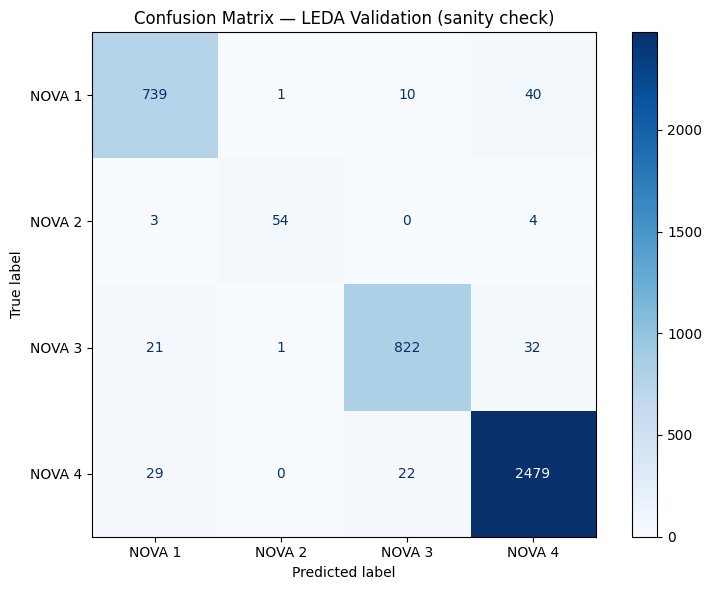

In [12]:
# Load best model
model = torch.load(f"{MODEL_FOLDER}/trained_bert_model_{MODEL_NAME}.pth", map_location=device, weights_only=False)

print("Evaluating on LEDA validation set...")
y_true_val, y_pred_val, y_probs_val = run_inference(
    model, encoded_dataset["validation"], device, BATCH_SIZE
)
print_results(y_true_val, y_pred_val, y_probs_val, LABEL_NAMES,
              title="LEDA Validation (sanity check)")

## 10. Evaluate on FLIP (External Test Set)

This is the main result: how well does LEDA-trained BERT generalise to a completely different food database?

Evaluating on FLIP external test set...
RESULTS: FLIP External Test (Train LEDA → Test FLIP)
              precision    recall  f1-score   support

      NOVA 1       0.76      0.30      0.43      1617
      NOVA 2       0.91      0.13      0.22       323
      NOVA 3       0.40      0.10      0.16      1942
      NOVA 4       0.79      0.98      0.88     11424

    accuracy                           0.78     15306
   macro avg       0.72      0.38      0.42     15306
weighted avg       0.74      0.78      0.73     15306

Per-class AUC-ROC: {'NOVA 1': np.float64(0.8973), 'NOVA 2': np.float64(0.7973), 'NOVA 3': np.float64(0.7356), 'NOVA 4': np.float64(0.8562)}
Per-class AUC-PR:  {'NOVA 1': np.float64(0.5769), 'NOVA 2': np.float64(0.2523), 'NOVA 3': np.float64(0.2777), 'NOVA 4': np.float64(0.9428)}

Macro AUC-ROC: 0.8216
Macro AUC-PR:  0.5124

Balanced Accuracy: 0.3779


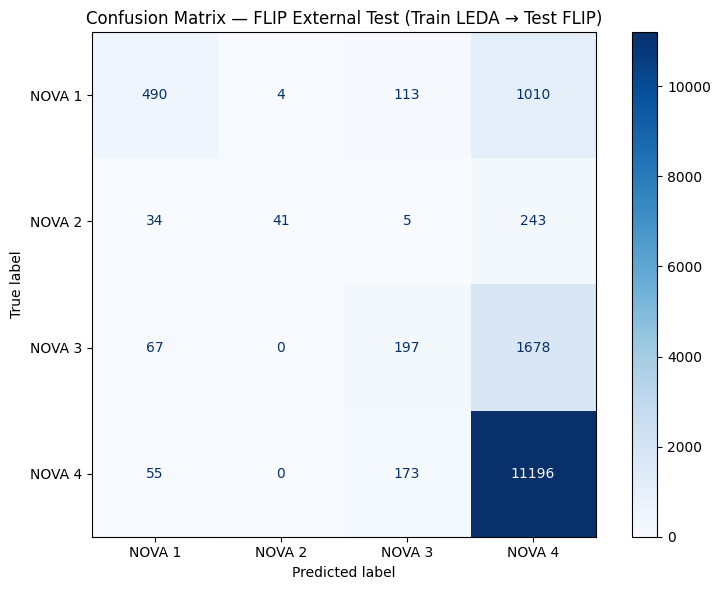

In [13]:
print("Evaluating on FLIP external test set...")
y_true_flip, y_pred_flip, y_probs_flip = run_inference(
    model, encoded_dataset["test"], device, BATCH_SIZE
)
print_results(y_true_flip, y_pred_flip, y_probs_flip, LABEL_NAMES,
              title="FLIP External Test (Train LEDA → Test FLIP)")

## 11. Side-by-Side Comparison

In [14]:
from sklearn.metrics import accuracy_score, f1_score

metrics = {
    "Metric": ["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"],
    "LEDA Val": [
        accuracy_score(y_true_val, y_pred_val),
        balanced_accuracy_score(y_true_val, y_pred_val),
        f1_score(y_true_val, y_pred_val, average="macro"),
        f1_score(y_true_val, y_pred_val, average="weighted"),
    ],
    "FLIP Test": [
        accuracy_score(y_true_flip, y_pred_flip),
        balanced_accuracy_score(y_true_flip, y_pred_flip),
        f1_score(y_true_flip, y_pred_flip, average="macro"),
        f1_score(y_true_flip, y_pred_flip, average="weighted"),
    ],
}

comparison_df = pd.DataFrame(metrics)
comparison_df["LEDA Val"] = comparison_df["LEDA Val"].round(4)
comparison_df["FLIP Test"] = comparison_df["FLIP Test"].round(4)
print(comparison_df.to_string(index=False))

           Metric  LEDA Val  FLIP Test
         Accuracy    0.9617     0.7790
Balanced Accuracy    0.9347     0.3779
         Macro F1    0.9457     0.4236
      Weighted F1    0.9616     0.7251


## 12. Error Analysis — Misclassified FLIP Products

In [15]:
flip_results = flip.copy()
flip_results["y_true"] = y_true_flip
flip_results["y_pred"] = y_pred_flip
flip_results["y_true_nova"] = [t + 1 for t in y_true_flip]
flip_results["y_pred_nova"] = [p + 1 for p in y_pred_flip]
flip_results["correct"] = flip_results["y_true"] == flip_results["y_pred"]

n_correct = flip_results["correct"].sum()
n_total = len(flip_results)
print(f"Correct: {n_correct}/{n_total} ({100*n_correct/n_total:.1f}%)")
print(f"Misclassified: {n_total - n_correct}")

# Show some misclassified examples
misclassified = flip_results[~flip_results["correct"]]
print(f"\nSample misclassified products:")
sample = misclassified.sample(min(10, len(misclassified)), random_state=42)
for _, row in sample.iterrows():
    print(f"  True: NOVA {row['y_true_nova']}, Pred: NOVA {row['y_pred_nova']}")
    print(f"    Product: {row['product_name']}")
    print(f"    Ingredients: {str(row['ingredients'])[:100]}...")
    print()

Correct: 11924/15306 (77.9%)
Misclassified: 3382

Sample misclassified products:
  True: NOVA 2, Pred: NOVA 3
    Product: Creamery Butter - Sea Salted
    Ingredients: cream (milk), sea salt....

  True: NOVA 1, Pred: NOVA 4
    Product: Pasta - Oven-Ready Lasagna
    Ingredients: durum wheat semolina, niacin, ferrous sulphate (iron), riboflavin, thiamine mononitrate, folic acid....

  True: NOVA 3, Pred: NOVA 4
    Product: Organic Rice Cakes - Brown Rice, Salted
    Ingredients: organic whole grain brown rice, sea salt....

  True: NOVA 3, Pred: NOVA 4
    Product: Baby Food - Harvest Pear, Pumpkin & Banana
    Ingredients: organic pear, organic banana, organic pumpkin, water, organic lemon juice concentrate, ascorbic acid...

  True: NOVA 2, Pred: NOVA 4
    Product: Celeb 100% Canola and Mid-Oleic Sunflower Oil Blend
    Ingredients: canola oil, mild-oleic sunflower oil....

  True: NOVA 3, Pred: NOVA 4
    Product: Crackers - Herb
    Ingredients: organic whole grain brown rice, 

## 13. Save and Download Results

In [16]:
# Save FLIP predictions
results_path = f"{MODEL_FOLDER}/flip_predictions_{MODEL_NAME}.csv"
flip_results.to_csv(results_path, index=False)
print(f"FLIP predictions saved to {results_path}")

# Download
from google.colab import files

print("\nDownloading model...")
files.download(f"{MODEL_FOLDER}/trained_bert_model_{MODEL_NAME}.pth")

print("Downloading FLIP predictions...")
files.download(results_path)

FLIP predictions saved to trained_leda_model/flip_predictions_leda_to_flip.csv



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>